<a href="https://colab.research.google.com/github/Anish-S-tech/car_damage_detection/blob/main/vehicle_damage_severity/Vehicle_damage_severity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
from google.colab import files
uploaded = files.upload()  # Upload your ZIP file (e.g., data3a.zip)


Saving damaged_car2.jpeg to damaged_car2.jpeg


In [2]:
import zipfile

with zipfile.ZipFile("car_damage_severity_dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")


In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


In [16]:
train_dir = "/content/data3a/training"
val_dir   = "/content/data3a/validation"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=(224,224), batch_size=32, class_mode='categorical'
)
val_gen = val_datagen.flow_from_directory(
    val_dir, target_size=(224,224), batch_size=32, class_mode='categorical'
)


Found 1383 images belonging to 3 classes.
Found 248 images belonging to 3 classes.


In [17]:
base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base.trainable = False  # Freeze the base model

x = GlobalAveragePooling2D()(base.output)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
output = Dense(3, activation='softmax')(x)

model = Model(base.input, output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [18]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, verbose=1),
    ModelCheckpoint("best_severity_model.h5", save_best_only=True)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=callbacks
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4703 - loss: 1.1784

44/44 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.4715 - loss: 1.1750 - val_accuracy: 0.6492 - val_loss: 0.7547 - learning_rate: 0.0010
Epoch 2/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6079 - loss: 0.8190

44/44 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.6080 - loss: 0.8188 - val_accuracy: 0.6653 - val_loss: 0.7404 - learning_rate: 0.0010
Epoch 3/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6373 - loss: 0.7626

44/44 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.6375 - loss: 0.7625 - val_accuracy: 0.6976 - val_loss: 0.6787 - learning_rate: 0.0010
Epoch 4/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.6859 - loss: 0.7114 - val_accuracy: 0.6815 - val_loss: 0.7145 - learning_rate: 0.0010
Epoch 5/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6692 - loss: 0.7513
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
44/44 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.6693 - loss: 0.7508 - val_accuracy: 0.6694 - val_loss: 0.7057 - learning_rate: 0.0010
Epoch 6/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.7008 - loss: 0.6868 - val_accuracy: 0.6815 - val_loss: 0.6997 - learning_rate: 3.0000e-04
Epoch 7/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7050 - loss: 0.6669

44/44 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.7048 - loss: 0.6669 - val_accuracy: 0.7016 - val_loss: 0.6700 - learning_rate: 3.0000e-04
Epoch 8/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.7022 - loss: 0.6739 - val_accuracy: 0.6855 - val_loss: 0.7164 - learning_rate: 3.0000e-04
Epoch 9/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7105 - loss: 0.6585
Epoch 9: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
44/44 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.7106 - loss: 0.6584 - val_accuracy: 0.6935 - val_loss: 0.6854 - learning_rate: 3.0000e-04
Epoch 10/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.7347 - loss: 0.6223 - val_accuracy: 0.6976 - val_loss: 0.6859 - learning_rate: 9.0000e-05
Epoch 11/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7212 - loss: 0.6492
Epoch 11: ReduceLROnPlateau reducing learning rate to 2.700000040931627e-05.
44/44 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.7210 - loss: 0.6493 - val_acc

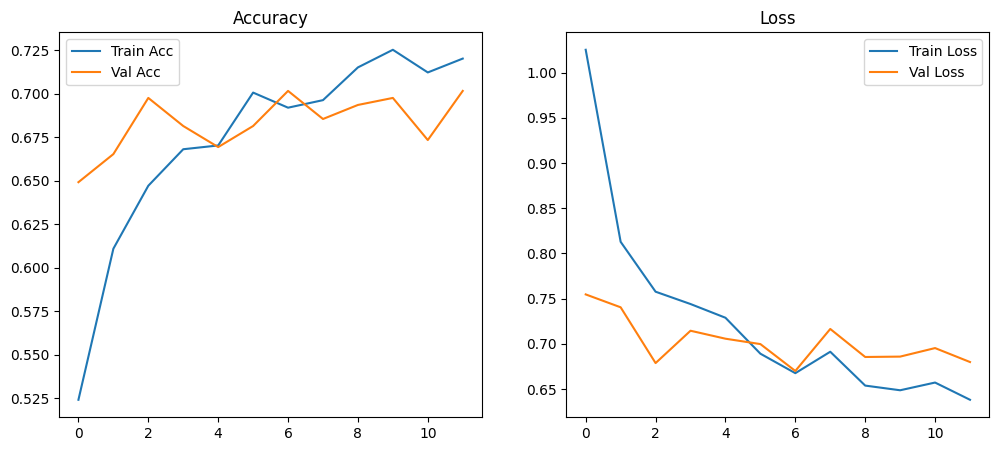

In [19]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()


In [20]:
model.save("severity_model.h5")


In [26]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

# Load saved model
model = load_model("severity_model.h5")

# Load and preprocess image
img = image.load_img("/content/damaged_car2.jpeg", target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)
classes = ['minor', 'moderate', 'severe']
print("Predicted:", classes[np.argmax(pred)])


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted: minor


In [27]:
pred = model.predict(img_array)[0]
for i, class_name in enumerate(['minor', 'moderate', 'severe']):
    print(f"{class_name}: {pred[i]*100:.2f}%")

print("Predicted:", ['minor', 'moderate', 'severe'][np.argmax(pred)])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
minor: 97.24%
moderate: 2.68%
severe: 0.08%
Predicted: minor


In [29]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [32]:
model.save("/content/drive/MyDrive/severity_model.h5")


In [31]:
from google.colab import files
files.download("severity_model.h5")  # Replace with your filename


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##  Regression Model: Cost Estimation from Car Damage Image


In [35]:
import os
import pandas as pd
import random

# Define path
base_path = "/content/data3a/training"

# Define label-cost mapping
cost_mapping = {
    "01-minor": (1000, 5000),
    "02-moderate": (5000, 15000),
    "03-severe": (15000, 40000)
}

# Collect image paths and random costs
data = []

for severity, (low, high) in cost_mapping.items():
    folder = os.path.join(base_path, severity)
    for filename in os.listdir(folder):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            full_path = os.path.join(folder, filename)
            cost = random.randint(low, high)
            data.append([full_path, cost])

# Save to CSV
df = pd.DataFrame(data, columns=["image_path", "repair_cost"])
df.to_csv("repair_cost_labels.csv", index=False)

print("✅ Labels saved to repair_cost_labels.csv")
df.head()


✅ Labels saved to repair_cost_labels.csv


,image_path,repair_cost
0,/content/data3a/training/01-minor/0206.JPEG,2950
1,/content/data3a/training/01-minor/0070.JPEG,2308
2,/content/data3a/training/01-minor/0069.JPEG,4888
3,/content/data3a/training/01-minor/0021.JPEG,2341
4,/content/data3a/training/01-minor/0046.JPEG,3437


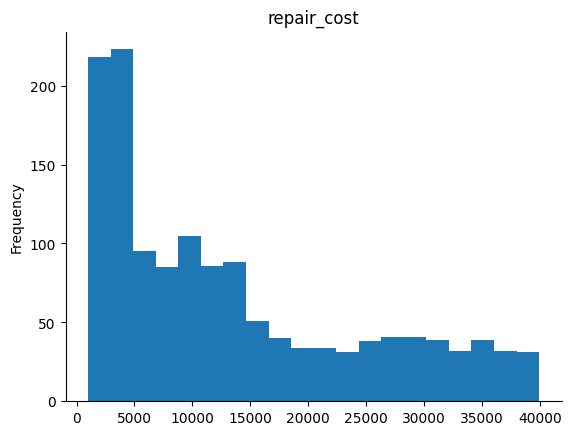

In [36]:
# @title repair_cost

from matplotlib import pyplot as plt
df['repair_cost'].plot(kind='hist', bins=20, title='repair_cost')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf


In [39]:
# Load CSV
df = pd.read_csv("/content/repair_cost_labels.csv")

# Resize and normalize images
IMG_SIZE = (224, 224)
images = []
costs = []

for i, row in df.iterrows():
    path = row["image_path"]
    cost = row["repair_cost"]
    try:
        img = load_img(path, target_size=IMG_SIZE)
        img = img_to_array(img) / 255.0
        images.append(img)
        costs.append(cost)
    except:
        print(f"Error loading: {path}")

images = np.array(images)
costs = np.array(costs).reshape(-1, 1)

# Normalize costs to [0, 1]
scaler = MinMaxScaler()
costs_scaled = scaler.fit_transform(costs)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(images, costs_scaled, test_size=0.2, random_state=42)


In [40]:
# Build model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='linear')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [41]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=25,
    batch_size=32
)


Epoch 1/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - loss: 1.8147 - mae: 0.9729 - val_loss: 0.0889 - val_mae: 0.2347
Epoch 2/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - loss: 0.0872 - mae: 0.2359 - val_loss: 0.0712 - val_mae: 0.2136
Epoch 3/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - loss: 0.0719 - mae: 0.2137 - val_loss: 0.0682 - val_mae: 0.2073
Epoch 4/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - loss: 0.0602 - mae: 0.1941 - val_loss: 0.0656 - val_mae: 0.2023
Epoch 5/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - loss: 0.0574 - mae: 0.1902 - val_loss: 0.0648 - val_mae: 0.1993
Epoch 6/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - loss: 0.0522 - mae: 0.1809 - val_loss: 0.0648 - val_mae: 0.1982
Epoch 7/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - loss: 0.0450 - mae: 0.1643 - val_loss: 0.0629 - val_mae: 0.1962
Epoch 8/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - loss: 0.0409 - mae: 0.1585 - val_loss: 0.0632 - val_mae: 0.1966
Epoch 9/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - loss: 0.0368 - mae: 

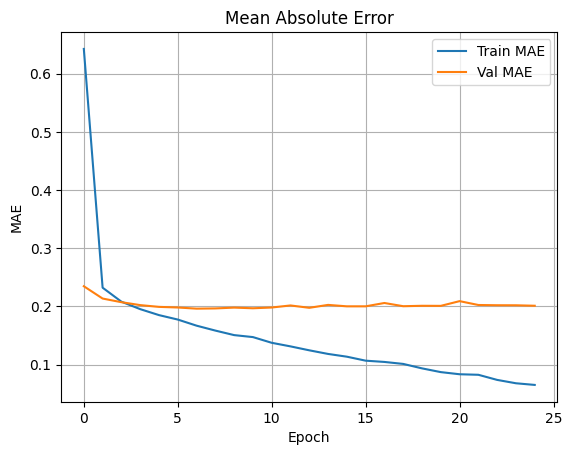

In [42]:
# Plot MAE
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Mean Absolute Error')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()


In [43]:
model.save("repair_cost_regression_model.h5")

import joblib
joblib.dump(scaler, "repair_cost_scaler.pkl")


['repair_cost_scaler.pkl']

In [59]:
from tensorflow.keras.preprocessing import image
import numpy as np

def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    return np.expand_dims(img_array, axis=0)



In [65]:
cost = predict_cost("/content/data3a/validation/01-minor/0002.JPEG")
print(cost)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
3226.2


In [66]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Setup scaler based on original range
scaler = MinMaxScaler()
scaler.fit(np.array([[0], [20000]]))  # Fit with min and max cost

# Simulated prediction from model (scaled)
predicted_scaled = 0.72  # Example output from model.predict()

# Inverse transform to get actual cost
predicted_actual = scaler.inverse_transform([[predicted_scaled]])[0][0]

# Actual ground truth cost
actual_cost = np.float64(cost)

# Error calculation
mae = abs(predicted_actual - actual_cost)

# Print results
print(f"Predicted Cost : ₹{predicted_actual:.2f}")
print(f"Actual Cost    : ₹{actual_cost:.2f}")
print(f"Absolute Error : ₹{mae:.2f}")


Predicted Cost : ₹14400.00
Actual Cost    : ₹3226.20
Absolute Error : ₹11173.80


In [62]:
# Load and preprocess the image like in training
img = tf.keras.preprocessing.image.load_img('/content/data3a/validation/01-minor/0001.JPEG', target_size=(224,224))
img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
scaled_pred = model.predict(img_array)[0][0]
pred_cost = scaler.inverse_transform([[scaled_pred]])[0][0]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Cost : ₹-0.04
Actual Cost    : ₹2950.00
Absolute Error : ₹2950.04


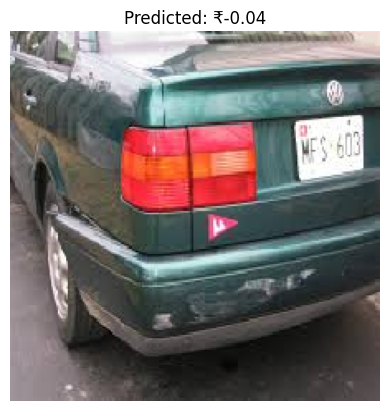

In [71]:
# Step 1: Imports
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Step 2: Load model
model = load_model("repair_cost_regression_model.h5", custom_objects={"mse": MeanSquaredError()})

# Step 3: Load cost label CSV (with correct column names)
cost_df = pd.read_csv("/content/repair_cost_labels.csv")  # update path if needed

# Step 4: Preprocessing function
def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    return np.expand_dims(img_array, axis=0)

# Step 5: Predict function
def predict_repair_cost(image_path):
    processed_img = preprocess_image(image_path)
    predicted_cost = model.predict(processed_img)[0][0]

    # Get actual cost from CSV
    actual_row = cost_df[cost_df["image_path"] == image_path]
    if not actual_row.empty:
        actual_cost = actual_row["repair_cost"].values[0]
        error = abs(predicted_cost - actual_cost)
        print(f"Predicted Cost : ₹{predicted_cost:.2f}")
        print(f"Actual Cost    : ₹{actual_cost:.2f}")
        print(f"Absolute Error : ₹{error:.2f}")
    else:
        print(f"Predicted Cost : ₹{predicted_cost:.2f}")
        print("Actual cost not found in CSV.")

    # Show the image
    img = image.load_img(image_path, target_size=(224, 224))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: ₹{predicted_cost:.2f}")
    plt.show()

# Step 6: Test the model
test_image = "/content/data3a/training/01-minor/0206.JPEG"  # change to your test image
predict_repair_cost(test_image)
